# foldsym quickstart

Run the fold symmetry pipeline end to end on **synthetic** nanodiffraction patterns with known ground truth. No private data needed.

```bash
pip install -e ".[dev]"   # from the repository root
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import foldsym
from foldsym import V1, V2, process_image, process_stack, summarize
from foldsym.synthetic import make_pattern, make_stack
from foldsym.viz import show_pattern, plot_distribution

print("foldsym", foldsym.__version__)

foldsym 1.0.0


## 1. One pattern, step by step

A synthetic 120 x 120 pattern with a central beam, an amorphous ring, multiplicative noise and four speckles.

detected speckles (y, x, radius):
[[26.2 59.9  7.6]
 [60.2 93.9  7.4]
 [60.2 26.   7.4]
 [93.9 60.   7.3]]
label: 4-fold


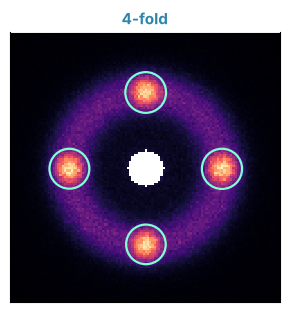

In [2]:
img = make_pattern(n_fold=4, rng=0)
speckles = foldsym.detect_circular_speckles(img, V1.detector)
label = foldsym.classify_pattern(speckles, img.shape, V1.classifier)

print("detected speckles (y, x, radius):")
print(np.round(speckles, 1))
print("label:", label)

fig, ax = plt.subplots(figsize=(3.5, 3.5))
show_pattern(ax, img, speckles, label);

## 2. A labelled stack

50 patterns per class. Compare the two configurations from the capstone.

v1 per-class accuracy: {'None': 0.0, '2-fold': 1.0, '3-fold (Odd)': 1.0, '4-fold': 1.0, '5-fold (Odd)': 1.0, '6-fold': 1.0}


v2 per-class accuracy: {'None': 1.0, '2-fold': 0.02, '3-fold (Odd)': 0.9, '4-fold': 1.0, '5-fold (Odd)': 1.0, '6-fold': 1.0}


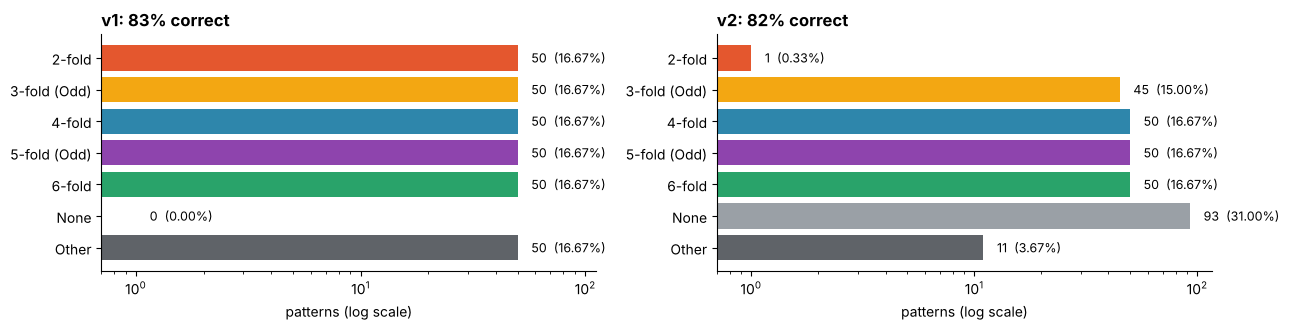

In [3]:
truth = np.repeat([0, 2, 3, 4, 5, 6], 50)
stack = make_stack(truth, rng=1)
expected = {0: "None", 2: "2-fold", 3: "3-fold (Odd)", 4: "4-fold", 5: "5-fold (Odd)", 6: "6-fold"}

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
for ax, cfg in zip(axes, (V1, V2)):
    labels = [r.label for r in process_stack(stack, cfg, progress=False)]
    acc = np.mean([l == expected[t] for l, t in zip(labels, truth)])
    plot_distribution(summarize(labels), ax, title=f"{cfg.name}: {acc:.0%} correct")
    print(cfg.name, "per-class accuracy:",
          {expected[n]: float(np.mean([l == expected[n] for l, t in zip(labels, truth) if t == n])) for n in expected})
fig.tight_layout()

Two things show up even on clean synthetic data:

* **v1** labels speckle-free patterns as *Other*, because noise on the amorphous ring passes its looser size filter.
* **v2** misses most 2-fold patterns: with only two speckles, its 92nd percentile threshold also captures the ring, so the speckles merge into it.

Both are consistent with the real data, where v2 found 2,004 two-fold patterns versus 3,221 for v1.

## 3. Orientation sensitivity

The ideal n-fold angles start at 0 degrees, so the rule only fires when speckles happen to line up with the detector axes. Rotating the same pattern breaks detection once the offset exceeds the angular tolerance.

In [4]:
for n, name in [(4, "4-fold"), (6, "6-fold")]:
    for rot in (0, 5, 10, 15, 30):
        hit = np.mean([process_image(make_pattern(n, rotation_deg=rot, rng=s), V1).label == name for s in range(20)])
        print(f"{name}, rotated {rot:>2} deg: detected {hit:.0%}")

4-fold, rotated  0 deg: detected 100%
4-fold, rotated  5 deg: detected 100%
4-fold, rotated 10 deg: detected 100%


4-fold, rotated 15 deg: detected 0%
4-fold, rotated 30 deg: detected 0%
6-fold, rotated  0 deg: detected 100%


6-fold, rotated  5 deg: detected 100%
6-fold, rotated 10 deg: detected 0%


6-fold, rotated 15 deg: detected 0%
6-fold, rotated 30 deg: detected 0%


## 4. Your own data

Any `(N, H, W)` TIFF or `.npy` stack works:

```bash
foldsym run path/to/stack.tif --config v1 --out results/v1
```

This writes `labels.csv`, `summary.json` and `distribution.png`.